# 05 — Few-Shot Fine-Tuning for Cross-Domain NER

This notebook adapts the CoNLL-2003 baseline model from Notebook 04 to the two target domains:

- **WNUT-17** — noisy, emerging, and social-media entities
- **SciERC** — scientific entities

It trains one model for every combination of:

- Budgets: **50, 100, and 200 sentences**
- Seeds: **13, 42, and 101**
- Target datasets: **WNUT-17 and SciERC**

## Important label-space decision

The baseline model has a CoNLL-specific output head, while WNUT-17 and SciERC use different entity types. Directly reusing the CoNLL classification head would therefore be incorrect.

For each target-domain run, this notebook:

1. Loads the **encoder weights learned from CoNLL-2003**.
2. Creates a fresh classification head sized for the target dataset.
3. Fine-tunes the complete model on the selected few-shot split.
4. Evaluates on the target-domain validation and test sets.

Two test metrics are reported:

- **Typed entity F1:** entity boundary and target-domain type must both be correct.
- **Boundary-only F1:** only the entity span must be correct, allowing direct comparison with the zero-shot results from Notebook 04.


In [1]:
!pip -q install "transformers==4.44.2" "datasets==2.19.2" "seqeval==1.2.2" "accelerate>=0.26.0" pandas matplotlib

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. In Colab, select Runtime > Change runtime type > GPU.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 49.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
GPU available: True
GPU

## Step 1 — Mount Drive and configure the experiment

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_from_disk
from seqeval.metrics import precision_score, recall_score, f1_score
from transformers import (
    AutoConfig,
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

PROCESSED = Path("/content/drive/MyDrive/AAI590/data/processed")
TOKENIZED_DIR = PROCESSED / "tokenized"
LABELS_DIR = PROCESSED / "label_maps"
MODELS_DIR = PROCESSED / "models"
RESULTS_DIR = PROCESSED / "results"
BASELINE_DIR = MODELS_DIR / "baseline_conll2003"

FEWSHOT_RESULTS_DIR = RESULTS_DIR / "fewshot"
FEWSHOT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Experiment settings created in Notebooks 02 and 03
TARGET_DATASETS = ["wnut17", "scierc"]
BUDGETS = [50, 100, 200]
SEEDS = [13, 42, 101]

# Fine-tuning settings
LEARNING_RATE = 2e-5
NUM_EPOCHS = 8
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

# Saving all 18 models can consume substantial Drive space.
# Set True only when you need every trained model later.
SAVE_ALL_MODELS = False

required_paths = [TOKENIZED_DIR, LABELS_DIR, BASELINE_DIR]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required path: {path}\n"
            "Run Notebooks 03 and 04 successfully before running Notebook 05."
        )

print("Processed directory:", PROCESSED)
print("Baseline model:", BASELINE_DIR)
print("Results directory:", FEWSHOT_RESULTS_DIR)


Mounted at /content/drive
Processed directory: /content/drive/MyDrive/AAI590/data/processed
Baseline model: /content/drive/MyDrive/AAI590/data/processed/models/baseline_conll2003
Results directory: /content/drive/MyDrive/AAI590/data/processed/results/fewshot


## Step 2 — Load the baseline model and tokenizer

Only the baseline model's **BERT encoder** is transferred to each target-domain model.  
The target classification head is newly initialized because each dataset has its own label inventory.


In [3]:
tokenizer = AutoTokenizer.from_pretrained(str(BASELINE_DIR))
baseline_model = AutoModelForTokenClassification.from_pretrained(str(BASELINE_DIR))

print("Baseline architecture:", baseline_model.config.model_type)
print("Baseline output labels:", baseline_model.config.num_labels)
print("Baseline encoder loaded successfully.")


Baseline architecture: bert
Baseline output labels: 8
Baseline encoder loaded successfully.


## Step 3 — Helper functions

In [4]:
def load_label_map(dataset_name):
    path = LABELS_DIR / f"{dataset_name}_label_map.json"
    with open(path) as f:
        mapping = json.load(f)

    label2id = {str(k): int(v) for k, v in mapping["label2id"].items()}
    id2label = {int(k): str(v) for k, v in mapping["id2label"].items()}
    return label2id, id2label


def collapse_to_boundary(tag):
    """Convert a typed BIO tag to O, B-ENT, or I-ENT."""
    if tag == "O":
        return "O"
    if tag.startswith("B-"):
        return "B-ENT"
    if tag.startswith("I-"):
        return "I-ENT"
    raise ValueError(f"Unexpected BIO tag: {tag}")


def decode_predictions(eval_pred, id2label):
    """Decode non-ignored labels and predictions into BIO tag sequences."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_tags = []
    predicted_tags = []

    for pred_row, label_row in zip(predictions, labels):
        sentence_true = []
        sentence_pred = []

        for pred_id, label_id in zip(pred_row, label_row):
            if label_id == -100:
                continue

            sentence_true.append(id2label[int(label_id)])
            sentence_pred.append(id2label[int(pred_id)])

        true_tags.append(sentence_true)
        predicted_tags.append(sentence_pred)

    return true_tags, predicted_tags


def build_compute_metrics(id2label):
    """Create a Trainer metric function for a target dataset's label map."""
    def compute_metrics(eval_pred):
        true_tags, predicted_tags = decode_predictions(eval_pred, id2label)

        true_boundary = [
            [collapse_to_boundary(tag) for tag in sentence]
            for sentence in true_tags
        ]
        predicted_boundary = [
            [collapse_to_boundary(tag) for tag in sentence]
            for sentence in predicted_tags
        ]

        return {
            "typed_precision": precision_score(true_tags, predicted_tags),
            "typed_recall": recall_score(true_tags, predicted_tags),
            "typed_f1": f1_score(true_tags, predicted_tags),
            "boundary_precision": precision_score(true_boundary, predicted_boundary),
            "boundary_recall": recall_score(true_boundary, predicted_boundary),
            "boundary_f1": f1_score(true_boundary, predicted_boundary),
        }

    return compute_metrics


def load_target_datasets(dataset_name, budget, seed):
    fewshot_path = (
        TOKENIZED_DIR / "fewshot" / dataset_name /
        f"budget{budget}_seed{seed}"
    )
    validation_path = TOKENIZED_DIR / dataset_name / "validation"
    test_path = TOKENIZED_DIR / dataset_name / "test"

    for path in [fewshot_path, validation_path, test_path]:
        if not path.exists():
            raise FileNotFoundError(
                f"Missing tokenized dataset: {path}\n"
                "Re-run Notebook 03 to create all tokenized few-shot splits."
            )

    return (
        load_from_disk(str(fewshot_path)),
        load_from_disk(str(validation_path)),
        load_from_disk(str(test_path)),
    )


def create_target_model(dataset_name):
    """Create a target-label model initialized with the CoNLL-trained encoder."""
    label2id, id2label = load_label_map(dataset_name)

    config = AutoConfig.from_pretrained(
        "bert-base-cased",
        num_labels=len(id2label),
        label2id=label2id,
        id2label=id2label,
    )

    target_model = AutoModelForTokenClassification.from_pretrained(
        "bert-base-cased",
        config=config,
        ignore_mismatched_sizes=True,
    )

    # Transfer the source-domain representation learned in Notebook 04.
    target_model.base_model.load_state_dict(
        baseline_model.base_model.state_dict(),
        strict=True,
    )

    return target_model, label2id, id2label


def cleanup_memory(*objects):
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Step 4 — Sanity-check all required inputs

This catches missing splits before starting a long training loop.


In [5]:
input_rows = []

for dataset_name in TARGET_DATASETS:
    label2id, id2label = load_label_map(dataset_name)

    for split in ["validation", "test"]:
        path = TOKENIZED_DIR / dataset_name / split
        input_rows.append({
            "dataset": dataset_name,
            "split": split,
            "budget": None,
            "seed": None,
            "exists": path.exists(),
            "path": str(path),
            "num_labels": len(id2label),
        })

    for budget in BUDGETS:
        for seed in SEEDS:
            path = (
                TOKENIZED_DIR / "fewshot" / dataset_name /
                f"budget{budget}_seed{seed}"
            )
            input_rows.append({
                "dataset": dataset_name,
                "split": "fewshot_train",
                "budget": budget,
                "seed": seed,
                "exists": path.exists(),
                "path": str(path),
                "num_labels": len(id2label),
            })

input_check_df = pd.DataFrame(input_rows)
display(input_check_df)

missing = input_check_df.loc[~input_check_df["exists"]]
if not missing.empty:
    raise FileNotFoundError(
        "Some required inputs are missing. Re-run Notebook 03.\n" +
        "\n".join(missing["path"].tolist())
    )

print("All required inputs are available.")


,dataset,split,budget,seed,exists,path,num_labels
0,wnut17,validation,NaN,NaN,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
1,wnut17,test,NaN,NaN,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
2,wnut17,fewshot_train,50.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
3,wnut17,fewshot_train,50.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
4,wnut17,fewshot_train,50.0,101.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
5,wnut17,fewshot_train,100.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
6,wnut17,fewshot_train,100.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
7,wnut17,fewshot_train,100.0,101.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
8,wnut17,fewshot_train,200.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
9,wnut17,fewshot_train,200.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13


All required inputs are available.


## Step 5 — Train one few-shot model

The validation set selects the checkpoint with the best **typed entity F1**.  
The final selected model is then evaluated once on the held-out target test set.


In [6]:
from transformers import EarlyStoppingCallback

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)


def run_fewshot_experiment(dataset_name, budget, seed):
    print("=" * 80)
    print(f"Dataset={dataset_name} | Budget={budget} | Seed={seed}")
    print("=" * 80)

    set_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    train_ds, validation_ds, test_ds = load_target_datasets(
        dataset_name, budget, seed
    )
    model, label2id, id2label = create_target_model(dataset_name)

    run_name = f"{dataset_name}_budget{budget}_seed{seed}"
    checkpoint_dir = Path("/content/fewshot_checkpoints") / run_name

    training_args = TrainingArguments(
        output_dir=str(checkpoint_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="typed_f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        seed=seed,
        data_seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=validation_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=build_compute_metrics(id2label),
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE
            )
        ],
    )

    train_output = trainer.train()
    validation_metrics = trainer.evaluate(validation_ds)
    test_metrics = trainer.evaluate(test_ds, metric_key_prefix="test")

    if SAVE_ALL_MODELS:
        model_output_dir = (
            MODELS_DIR / "fewshot" / dataset_name /
            f"budget{budget}_seed{seed}"
        )
        model_output_dir.mkdir(parents=True, exist_ok=True)
        trainer.save_model(str(model_output_dir))
        tokenizer.save_pretrained(str(model_output_dir))
        saved_model_path = str(model_output_dir)
    else:
        saved_model_path = None

    result = {
        "dataset": dataset_name,
        "budget": budget,
        "seed": seed,
        "num_train_sentences": len(train_ds),
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_validation_metric": trainer.state.best_metric,
        "training_loss": train_output.training_loss,
        "validation_typed_precision": validation_metrics.get("eval_typed_precision"),
        "validation_typed_recall": validation_metrics.get("eval_typed_recall"),
        "validation_typed_f1": validation_metrics.get("eval_typed_f1"),
        "validation_boundary_precision": validation_metrics.get("eval_boundary_precision"),
        "validation_boundary_recall": validation_metrics.get("eval_boundary_recall"),
        "validation_boundary_f1": validation_metrics.get("eval_boundary_f1"),
        "test_typed_precision": test_metrics.get("test_typed_precision"),
        "test_typed_recall": test_metrics.get("test_typed_recall"),
        "test_typed_f1": test_metrics.get("test_typed_f1"),
        "test_boundary_precision": test_metrics.get("test_boundary_precision"),
        "test_boundary_recall": test_metrics.get("test_boundary_recall"),
        "test_boundary_f1": test_metrics.get("test_boundary_f1"),
        "saved_model_path": saved_model_path,
    }

    print("\nTest results:")
    print(f"  Typed F1:   {result['test_typed_f1']:.4f}")
    print(f"  Boundary F1:{result['test_boundary_f1']:.4f}")

    cleanup_memory(trainer, model, train_ds, validation_ds, test_ds)
    return result


## Step 6 — Run the complete experiment grid

There are **18 runs** in total:

- 2 target datasets
- 3 budgets
- 3 random seeds



In [7]:
RESULTS_CSV = FEWSHOT_RESULTS_DIR / "fewshot_results.csv"
RESULTS_JSON = FEWSHOT_RESULTS_DIR / "fewshot_results.json"

if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV)
    completed = {
        (row.dataset, int(row.budget), int(row.seed))
        for row in results_df.itertuples()
    }
    all_results = results_df.to_dict("records")
    print(f"Resuming from {len(all_results)} completed runs.")
else:
    completed = set()
    all_results = []

for dataset_name in TARGET_DATASETS:
    for budget in BUDGETS:
        for seed in SEEDS:
            key = (dataset_name, budget, seed)

            if key in completed:
                print("Skipping completed run:", key)
                continue

            result = run_fewshot_experiment(dataset_name, budget, seed)
            all_results.append(result)
            completed.add(key)

            # Save immediately after each run.
            results_df = pd.DataFrame(all_results).sort_values(
                ["dataset", "budget", "seed"]
            )
            results_df.to_csv(RESULTS_CSV, index=False)

            with open(RESULTS_JSON, "w") as f:
                json.dump(
                    results_df.replace({np.nan: None}).to_dict("records"),
                    f,
                    indent=2,
                    default=str,
                )

            print("Saved progress to:", RESULTS_CSV)

results_df = pd.DataFrame(all_results).sort_values(
    ["dataset", "budget", "seed"]
).reset_index(drop=True)

display(results_df)


Dataset=wnut17 | Budget=50 | Seed=13


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Typed Precision,Typed Recall,Typed F1,Boundary Precision,Boundary Recall,Boundary F1
1,1.155900,0.893434,0.068445,0.072750,0.070532,0.298246,0.251541,0.272910
2,0.734800,0.819571,0.139851,0.139334,0.139592,0.485714,0.335388,0.396791
3,0.580800,0.716087,0.229508,0.327990,0.270051,0.617612,0.631319,0.624390
4,0.465300,0.688479,0.298156,0.358816,0.325686,0.632626,0.588163,0.609585
5,0.363400,0.661613,0.345880,0.419236,0.379041,0.645244,0.618989,0.631844
6,0.290100,0.680909,0.378902,0.434032,0.404598,0.651554,0.620222,0.635502
7,0.244500,0.664835,0.384535,0.453761,0.416290,0.657828,0.642417,0.650031
8,0.219200,0.681735,0.385272,0.445129,0.413043,0.655128,0.630086,0.642363


early stopping required metric_for_best_model, but did not find eval_typed_f1 so early stopping is disabled



Test results:
  Typed F1:   0.3786
  Boundary F1:0.6227
Saved progress to: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/fewshot_results.csv


,dataset,budget,seed,num_train_sentences,best_checkpoint,best_validation_metric,training_loss,validation_typed_precision,validation_typed_recall,validation_typed_f1,validation_boundary_precision,validation_boundary_recall,validation_boundary_f1,test_typed_precision,test_typed_recall,test_typed_f1,test_boundary_precision,test_boundary_recall,test_boundary_f1,saved_model_path
0,scierc,50,13,50,/content/fewshot_checkpoints/scierc_budget50_s...,0.160776,0.896251,0.183544,0.143033,0.160776,0.496503,0.350185,0.410701,0.177717,0.154486,0.165289,0.513962,0.404875,0.452943,None
1,scierc,50,42,50,/content/fewshot_checkpoints/scierc_budget50_s...,0.186508,0.748844,0.201141,0.173859,0.186508,0.489039,0.357583,0.413105,0.167231,0.146762,0.156329,0.480816,0.350178,0.405229,None
2,scierc,50,101,50,/content/fewshot_checkpoints/scierc_budget50_s...,0.143287,0.858024,0.140000,0.146732,0.143287,0.389245,0.374846,0.381910,0.119978,0.131313,0.125390,0.399167,0.398930,0.399048,None
3,scierc,100,13,100,/content/fewshot_checkpoints/scierc_budget100_...,0.259304,0.685797,0.252632,0.266338,0.259304,0.557084,0.499383,0.526658,0.227516,0.252525,0.239369,0.538221,0.510702,0.524100,None
4,scierc,100,42,100,/content/fewshot_checkpoints/scierc_budget100_...,0.279299,0.635409,0.251232,0.314427,0.279299,0.576293,0.563502,0.569825,0.248000,0.313131,0.276786,0.579587,0.567182,0.573317,None
5,scierc,100,101,100,/content/fewshot_checkpoints/scierc_budget100_...,0.218566,0.706756,0.208754,0.229346,0.218566,0.547584,0.461159,0.500669,0.209660,0.226976,0.217974,0.574306,0.491677,0.529789,None
6,scierc,200,13,200,/content/fewshot_checkpoints/scierc_budget200_...,0.381332,0.535571,0.354123,0.413070,0.381332,0.622829,0.618989,0.620903,0.338133,0.404635,0.368407,0.620370,0.637337,0.628739,None
7,scierc,200,42,200,/content/fewshot_checkpoints/scierc_budget200_...,0.418315,0.468614,0.386221,0.456227,0.418315,0.610843,0.625154,0.617916,0.336852,0.417112,0.372710,0.606576,0.636147,0.621010,None
8,scierc,200,101,200,/content/fewshot_checkpoints/scierc_budget200_...,0.416290,0.506733,0.384535,0.453761,0.416290,0.657828,0.642417,0.650031,0.349975,0.412359,0.378614,0.622328,0.623068,0.622698,None
9,wnut17,50,13,50,/content/fewshot_checkpoints/wnut17_budget50_s...,0.416230,0.471765,0.459538,0.380383,0.416230,0.572052,0.470096,0.516087,0.346113,0.301205,0.322101,0.506452,0.436515,0.468890,None


## Step 7 — Aggregate results across seeds

In [8]:
metric_columns = [
    "test_typed_precision",
    "test_typed_recall",
    "test_typed_f1",
    "test_boundary_precision",
    "test_boundary_recall",
    "test_boundary_f1",
]

summary_df = (
    results_df
    .groupby(["dataset", "budget"])[metric_columns]
    .agg(["mean", "std"])
    .reset_index()
)

# Flatten the multi-level column names.
summary_df.columns = [
    "_".join(str(part) for part in col if str(part))
    if isinstance(col, tuple) else col
    for col in summary_df.columns
]

summary_path = FEWSHOT_RESULTS_DIR / "fewshot_summary_by_budget.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df.round(4))
print("Saved summary to:", summary_path)


,dataset,budget,test_typed_precision_mean,test_typed_precision_std,test_typed_recall_mean,test_typed_recall_std,test_typed_f1_mean,test_typed_f1_std,test_boundary_precision_mean,test_boundary_precision_std,test_boundary_recall_mean,test_boundary_recall_std,test_boundary_f1_mean,test_boundary_f1_std
0,scierc,50,0.1550,0.0308,0.1442,0.0118,0.1490,0.0209,0.4646,0.0591,0.3847,0.0300,0.4191,0.0295
1,scierc,100,0.2284,0.0192,0.2642,0.0443,0.2447,0.0298,0.5640,0.0225,0.5232,0.0393,0.5424,0.0269
2,scierc,200,0.3417,0.0072,0.4114,0.0063,0.3732,0.0051,0.6164,0.0086,0.6322,0.0079,0.6241,0.0041
3,wnut17,50,0.3220,0.0227,0.2762,0.0321,0.2971,0.0278,0.4827,0.0206,0.4115,0.0321,0.4440,0.0255
4,wnut17,100,0.3498,0.0044,0.3475,0.0112,0.3486,0.0047,0.5119,0.0119,0.5054,0.0093,0.5085,0.0031
5,wnut17,200,0.4025,0.0283,0.4044,0.0330,0.4027,0.0238,0.5677,0.0184,0.5647,0.0394,0.5653,0.0145


Saved summary to: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/fewshot_summary_by_budget.csv


## Step 8 — Add Notebook 04 zero-shot results

The zero-shot baseline contains only boundary-level cross-domain metrics because the source and target entity types are incompatible. These values are added as budget **0** for the boundary comparison.


In [9]:
BASELINE_RESULTS_PATH = RESULTS_DIR / "baseline_results.json"

comparison_rows = []

if BASELINE_RESULTS_PATH.exists():
    with open(BASELINE_RESULTS_PATH) as f:
        baseline_results = json.load(f)

    zero_shot = baseline_results.get(
        "zero_shot_cross_domain_boundary_f1", {}
    )

    for dataset_name in TARGET_DATASETS:
        values = zero_shot.get(dataset_name)
        if values:
            comparison_rows.append({
                "dataset": dataset_name,
                "budget": 0,
                "method": "Zero-shot baseline",
                "boundary_f1_mean": values.get("f1"),
                "boundary_f1_std": 0.0,
            })
else:
    print(
        "Baseline results file was not found. "
        "Run Notebook 04 to include the zero-shot comparison."
    )

fewshot_boundary = (
    results_df
    .groupby(["dataset", "budget"])["test_boundary_f1"]
    .agg(["mean", "std"])
    .reset_index()
)

for row in fewshot_boundary.itertuples():
    comparison_rows.append({
        "dataset": row.dataset,
        "budget": int(row.budget),
        "method": "Few-shot fine-tuning",
        "boundary_f1_mean": row.mean,
        "boundary_f1_std": row.std,
    })

boundary_comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(["dataset", "budget"])
    .reset_index(drop=True)
)

comparison_path = FEWSHOT_RESULTS_DIR / "zero_vs_fewshot_boundary_comparison.csv"
boundary_comparison_df.to_csv(comparison_path, index=False)

display(boundary_comparison_df.round(4))
print("Saved comparison to:", comparison_path)


,dataset,budget,method,boundary_f1_mean,boundary_f1_std
0,scierc,0,Zero-shot baseline,0.0684,0.0000
1,scierc,50,Few-shot fine-tuning,0.4191,0.0295
2,scierc,100,Few-shot fine-tuning,0.5424,0.0269
3,scierc,200,Few-shot fine-tuning,0.6241,0.0041
4,wnut17,0,Zero-shot baseline,0.6095,0.0000
5,wnut17,50,Few-shot fine-tuning,0.4440,0.0255
6,wnut17,100,Few-shot fine-tuning,0.5085,0.0031
7,wnut17,200,Few-shot fine-tuning,0.5653,0.0145


Saved comparison to: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/zero_vs_fewshot_boundary_comparison.csv


## Step 9 — Plot learning curves

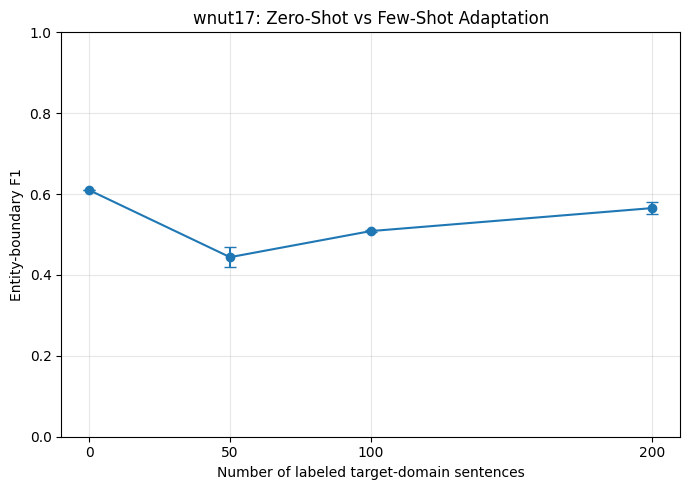

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/wnut17_boundary_learning_curve.png


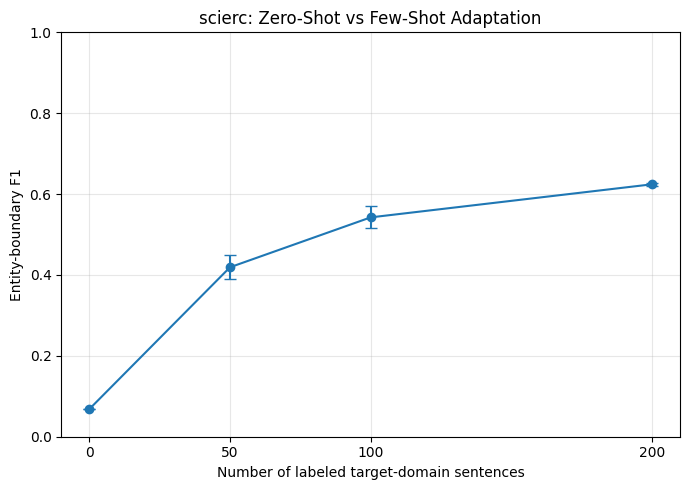

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/scierc_boundary_learning_curve.png


In [10]:
# Boundary-only F1: direct zero-shot versus few-shot comparison
for dataset_name in TARGET_DATASETS:
    plot_df = boundary_comparison_df[
        boundary_comparison_df["dataset"] == dataset_name
    ].sort_values("budget")

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        plot_df["budget"],
        plot_df["boundary_f1_mean"],
        yerr=plot_df["boundary_f1_std"].fillna(0),
        marker="o",
        capsize=4,
    )
    plt.xlabel("Number of labeled target-domain sentences")
    plt.ylabel("Entity-boundary F1")
    plt.title(f"{dataset_name}: Zero-Shot vs Few-Shot Adaptation")
    plt.xticks(sorted(plot_df["budget"].unique()))
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_path = (
        FEWSHOT_RESULTS_DIR /
        f"{dataset_name}_boundary_learning_curve.png"
    )
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


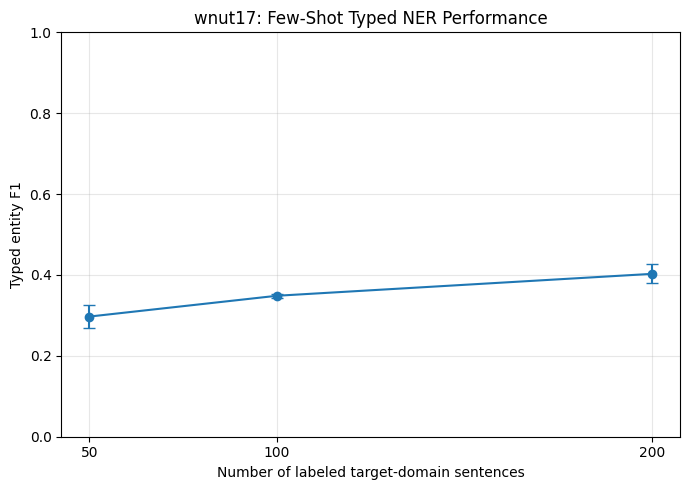

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/wnut17_typed_learning_curve.png


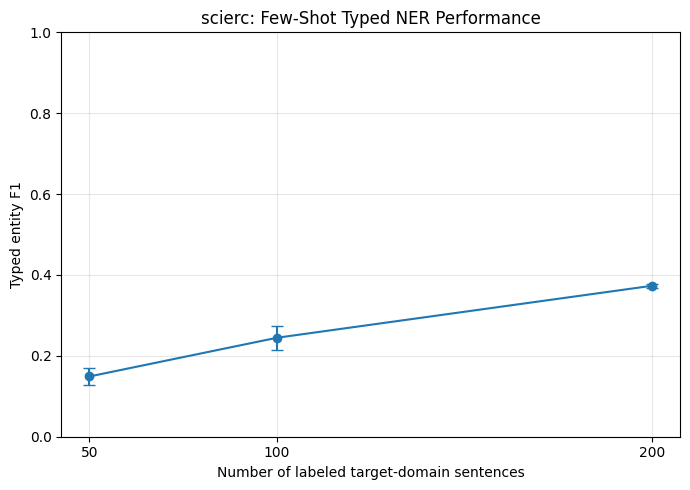

Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/scierc_typed_learning_curve.png


In [11]:
# Typed target-domain F1: available after few-shot adaptation
typed_summary = (
    results_df
    .groupby(["dataset", "budget"])["test_typed_f1"]
    .agg(["mean", "std"])
    .reset_index()
)

for dataset_name in TARGET_DATASETS:
    plot_df = typed_summary[
        typed_summary["dataset"] == dataset_name
    ].sort_values("budget")

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        plot_df["budget"],
        plot_df["mean"],
        yerr=plot_df["std"].fillna(0),
        marker="o",
        capsize=4,
    )
    plt.xlabel("Number of labeled target-domain sentences")
    plt.ylabel("Typed entity F1")
    plt.title(f"{dataset_name}: Few-Shot Typed NER Performance")
    plt.xticks(sorted(plot_df["budget"].unique()))
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_path = (
        FEWSHOT_RESULTS_DIR /
        f"{dataset_name}_typed_learning_curve.png"
    )
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


## Step 10 — Create a presentation-ready results table

In [12]:
presentation_rows = []

for dataset_name in TARGET_DATASETS:
    zero_row = boundary_comparison_df[
        (boundary_comparison_df["dataset"] == dataset_name) &
        (boundary_comparison_df["budget"] == 0)
    ]

    if not zero_row.empty:
        presentation_rows.append({
            "Dataset": dataset_name,
            "Training setup": "Zero-shot",
            "Budget": 0,
            "Typed F1": "N/A",
            "Boundary F1": f"{zero_row.iloc[0]['boundary_f1_mean']:.3f}",
        })

    for budget in BUDGETS:
        subset = results_df[
            (results_df["dataset"] == dataset_name) &
            (results_df["budget"] == budget)
        ]

        presentation_rows.append({
            "Dataset": dataset_name,
            "Training setup": "Few-shot",
            "Budget": budget,
            "Typed F1": (
                f"{subset['test_typed_f1'].mean():.3f} "
                f"± {subset['test_typed_f1'].std():.3f}"
            ),
            "Boundary F1": (
                f"{subset['test_boundary_f1'].mean():.3f} "
                f"± {subset['test_boundary_f1'].std():.3f}"
            ),
        })

presentation_df = pd.DataFrame(presentation_rows)
presentation_path = FEWSHOT_RESULTS_DIR / "presentation_results_table.csv"
presentation_df.to_csv(presentation_path, index=False)

display(presentation_df)
print("Saved:", presentation_path)


,Dataset,Training setup,Budget,Typed F1,Boundary F1
0,wnut17,Zero-shot,0,N/A,0.610
1,wnut17,Few-shot,50,0.297 ± 0.028,0.444 ± 0.025
2,wnut17,Few-shot,100,0.349 ± 0.005,0.508 ± 0.003
3,wnut17,Few-shot,200,0.403 ± 0.024,0.565 ± 0.014
4,scierc,Zero-shot,0,N/A,0.068
5,scierc,Few-shot,50,0.149 ± 0.021,0.419 ± 0.029
6,scierc,Few-shot,100,0.245 ± 0.030,0.542 ± 0.027
7,scierc,Few-shot,200,0.373 ± 0.005,0.624 ± 0.004


Saved: /content/drive/MyDrive/AAI590/data/processed/results/fewshot/presentation_results_table.csv


## Step 11 — Final output inventory

The main files produced by this notebook are:

- `fewshot_results.csv` — every individual run
- `fewshot_results.json` — every individual run in JSON format
- `fewshot_summary_by_budget.csv` — mean and standard deviation across seeds
- `zero_vs_fewshot_boundary_comparison.csv` — direct comparison with Notebook 04
- `presentation_results_table.csv` — compact table for the final presentation
- Boundary and typed-F1 learning-curve images for WNUT-17 and SciERC


In [13]:
print("Notebook 05 outputs:")
for path in sorted(FEWSHOT_RESULTS_DIR.glob("*")):
    print(" -", path.name)


Notebook 05 outputs:
 - fewshot_results.csv
 - fewshot_results.json
 - fewshot_summary_by_budget.csv
 - presentation_results_table.csv
 - scierc_boundary_learning_curve.png
 - scierc_typed_learning_curve.png
 - wnut17_boundary_learning_curve.png
 - wnut17_typed_learning_curve.png
 - zero_vs_fewshot_boundary_comparison.csv
